# Universal Precision Runtime (UPR) — Notebook 04
## Level 6 — Benchmarks, Plots & Competitive Comparison

---

### Objective
1. Load all precision sweep results from `results/variable_precision_summary.json`.
2. Generate all 8 paper-ready figures defined in `idea.md`.
3. Produce the competitive comparison table (UPR vs FP16 vs AWQ vs GPTQ).
4. Print a clean final summary report.

### Step 1: Environment Setup & Load Results

In [1]:
import os
import sys
import json

HF_TOKEN = "YOUR_HF_TOKEN_HERE"
os.environ["HF_TOKEN"] = HF_TOKEN

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = '/content/drive/MyDrive/UniversalPrecisionRuntime'
    os.makedirs(DRIVE_DIR, exist_ok=True)
    os.chdir(DRIVE_DIR)
except ImportError:
    pass

WORK_DIR = os.getcwd()
print(f"Working Directory: {WORK_DIR}")

!pip install -q matplotlib numpy

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Style setup
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#e6edf3',
    'axes.titlecolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'text.color': '#e6edf3',
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'legend.labelcolor': '#e6edf3',
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'lines.linewidth': 2.2,
    'lines.markersize': 8,
})

os.makedirs('results/plots', exist_ok=True)

# Load sweep summary
with open('results/variable_precision_summary.json', 'r') as f:
    summary = json.load(f)

baseline_ppl = summary['baseline_perplexity']
sweep = summary['precision_sweep']

bits       = [r['bits'] for r in sweep]
ppls       = [r['perplexity'] for r in sweep]
cos_sims   = [r['logit_cosine_similarity'] for r in sweep]
tok_accs   = [r['top1_token_accuracy_pct'] for r in sweep]
recon_time = [r['reconstruction_time_sec'] for r in sweep]

print(f"Loaded {len(sweep)} precision levels.")
print(f"Baseline FP16 Perplexity: {baseline_ppl:.4f}")
print(f"Bits tested: {bits}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working Directory: /content/drive/MyDrive/UniversalPrecisionRuntime
Loaded 8 precision levels.
Baseline FP16 Perplexity: 24.0684
Bits tested: [16, 14, 12, 10, 8, 6, 4, 2]


### Step 2: Generate All 8 Paper-Ready Figures

In [2]:
ACCENT   = '#58a6ff'
ACCENT2  = '#f78166'
ACCENT3  = '#56d364'
ACCENT4  = '#d2a8ff'
BASELINE = '#ffa657'

def save_fig(fig, name):
    path = f'results/plots/{name}'
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f'Saved: {path}')

# ── Figure 1: Perplexity vs Precision ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ppl_plot = [min(p, 200) for p in ppls]  # cap extreme values for readability
ax.plot(bits, ppl_plot, 'o-', color=ACCENT, label='BitPlane PPL')
ax.axhline(baseline_ppl, color=BASELINE, linestyle='--', label=f'FP16 Baseline ({baseline_ppl:.2f})')
ax.set_xlabel('Precision (bits)')
ax.set_ylabel('Perplexity (lower is better)')
ax.set_title('Figure 1 — Perplexity vs Precision')
ax.set_xticks(bits)
ax.invert_xaxis()
ax.legend()
ax.grid(True)
save_fig(fig, '01_perplexity_vs_precision.png')

# ── Figure 2: Logit Cosine Similarity vs Precision ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(bits, cos_sims, 's-', color=ACCENT2, label='Logit Cosine Similarity')
ax.axhline(1.0, color=BASELINE, linestyle='--', label='Perfect (1.0)')
ax.set_xlabel('Precision (bits)')
ax.set_ylabel('Cosine Similarity')
ax.set_title('Figure 2 — Logit Cosine Similarity vs Precision')
ax.set_xticks(bits)
ax.invert_xaxis()
ax.legend()
ax.grid(True)
save_fig(fig, '02_cosine_similarity_vs_precision.png')

# ── Figure 3: Top-1 Token Agreement vs Precision ──────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([str(b) for b in bits], tok_accs, color=[ACCENT3 if t == 100.0 else ACCENT2 for t in tok_accs], edgecolor='#21262d')
ax.axhline(100.0, color=BASELINE, linestyle='--', label='100% Agreement')
ax.set_xlabel('Precision (bits)')
ax.set_ylabel('Top-1 Agreement (%)')
ax.set_title('Figure 3 — Top-1 Token Agreement vs Precision')
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, axis='y')
save_fig(fig, '03_top1_agreement_vs_precision.png')

# ── Figure 4: Reconstruction Time vs Precision ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(bits, recon_time, 'D-', color=ACCENT4, label='Reconstruction Time (s)')
ax.set_xlabel('Precision (bits)')
ax.set_ylabel('Reconstruction Time (seconds)')
ax.set_title('Figure 4 — Reconstruction Time vs Precision')
ax.set_xticks(bits)
ax.invert_xaxis()
ax.legend()
ax.grid(True)
save_fig(fig, '04_reconstruction_time_vs_precision.png')

# ── Figure 5: Memory Loaded (Estimated) vs Precision ─────────────────────────
param_count = 836_000_000  # Qwen3.5-0.8B approximate params
bytes_loaded = [(b / 16) * param_count / (1024**2) for b in bits]  # MB
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(bits, bytes_loaded, '^-', color=ACCENT, label='Estimated MB Loaded')
ax.axhline(param_count * 2 / (1024**2), color=BASELINE, linestyle='--', label='FP16 Full Load')
ax.set_xlabel('Precision (bits)')
ax.set_ylabel('Estimated Memory Loaded (MB)')
ax.set_title('Figure 5 — Memory Loaded vs Precision')
ax.set_xticks(bits)
ax.invert_xaxis()
ax.legend()
ax.grid(True)
save_fig(fig, '05_memory_loaded_vs_precision.png')

# ── Figure 6: Perplexity Delta (vs Baseline) vs Precision ────────────────────
ppl_delta = [min(p, 200) - baseline_ppl for p in ppls]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([str(b) for b in bits], ppl_delta,
              color=[ACCENT3 if d < 0.5 else (ACCENT2 if d < 10 else ACCENT4) for d in ppl_delta],
              edgecolor='#21262d')
ax.axhline(0, color=BASELINE, linestyle='--', label='Baseline (delta=0)')
ax.set_xlabel('Precision (bits)')
ax.set_ylabel('PPL Delta vs FP16 Baseline')
ax.set_title('Figure 6 — Perplexity Degradation vs Precision')
ax.legend()
ax.grid(True, axis='y')
save_fig(fig, '06_perplexity_delta_vs_precision.png')

# ── Figure 7: Quality Cliff Map (CosSim + Token Acc + PPL normalized) ─────────
ppl_norm = [1.0 - min((p - baseline_ppl) / max(ppls), 1.0) for p in ppls]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(bits, [c/max(cos_sims) for c in cos_sims], 'o-', color=ACCENT, label='Cosine Similarity (norm)')
ax.plot(bits, [t/100.0 for t in tok_accs], 's-', color=ACCENT3, label='Top-1 Agreement (norm)')
ax.plot(bits, ppl_norm, '^-', color=ACCENT2, label='PPL Quality (norm, higher=better)')
ax.set_xlabel('Precision (bits)')
ax.set_ylabel('Normalized Score (0-1)')
ax.set_title('Figure 7 — Quality Cliff Map Across Precision Levels')
ax.set_xticks(bits)
ax.invert_xaxis()
ax.legend()
ax.grid(True)
save_fig(fig, '07_quality_cliff_map.png')

# ── Figure 8: Reconstruction Time vs Estimated Memory Tradeoff ────────────────
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(bytes_loaded, recon_time, c=bits, cmap='plasma', s=120, zorder=5)
for i, b in enumerate(bits):
    ax.annotate(f'{b}-bit', (bytes_loaded[i], recon_time[i]), textcoords='offset points',
                xytext=(8, 4), color='#e6edf3', fontsize=9)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Bits', color='#e6edf3')
cbar.ax.yaxis.set_tick_params(color='#8b949e')
ax.set_xlabel('Estimated Memory Loaded (MB)')
ax.set_ylabel('Reconstruction Time (seconds)')
ax.set_title('Figure 8 — Memory vs Reconstruction Time Tradeoff')
ax.grid(True)
save_fig(fig, '08_memory_vs_time_tradeoff.png')

print('\nAll 8 figures saved to results/plots/')

Saved: results/plots/01_perplexity_vs_precision.png
Saved: results/plots/02_cosine_similarity_vs_precision.png
Saved: results/plots/03_top1_agreement_vs_precision.png
Saved: results/plots/04_reconstruction_time_vs_precision.png
Saved: results/plots/05_memory_loaded_vs_precision.png
Saved: results/plots/06_perplexity_delta_vs_precision.png
Saved: results/plots/07_quality_cliff_map.png
Saved: results/plots/08_memory_vs_time_tradeoff.png

All 8 figures saved to results/plots/


### Step 3: Competitive Comparison Table

In [3]:
print('\n' + '='*85)
print('COMPETITIVE COMPARISON TABLE')
print('='*85)
print(f'{"Method":<22} | {"Single Checkpoint":<20} | {"Multi-Precision":<20} | {"Notes"}')
print('-'*85)
print(f'{"FP16 (HuggingFace)":<22} | {"Yes":<20} | {"No":<20} | Full quality, no precision choice')
print(f'{"AWQ":<22} | {"No":<20} | {"No":<20} | Per-precision separate checkpoints')
print(f'{"GPTQ":<22} | {"No":<20} | {"No":<20} | Per-precision separate checkpoints')
print(f'{"BitsAndBytes":<22} | {"No":<20} | {"No":<20} | Runtime quant, kernel-dependent')
print(f'{"BitPlane Runtime (UPR)":<22} | {"Yes":<20} | {"Yes":<20} | One checkpoint, any precision on demand')
print('='*85)

print('\n' + '='*85)
print('PRECISION SWEEP RESULTS SUMMARY')
print('='*85)
print(f'{"Bits":<6} | {"Recon(s)":<10} | {"CosSim":<10} | {"Top-1%":<10} | {"PPL":<12} | {"PPL Delta"}')
print('-'*70)
print(f'{"FP16":<6} | {"N/A":<10} | {"1.000000":<10} | {"100.00":<10} | {baseline_ppl:<12.4f} | 0.0000')
for r in sweep:
    delta = min(r['perplexity'], 9999) - baseline_ppl
    print(f"{r['bits']:<6} | {r['reconstruction_time_sec']:<10.2f} | {r['logit_cosine_similarity']:<10.6f} | {r['top1_token_accuracy_pct']:<10.2f} | {min(r['perplexity'],9999):<12.4f} | {delta:+.4f}")
print('='*85)


COMPETITIVE COMPARISON TABLE
Method                 | Single Checkpoint    | Multi-Precision      | Notes
-------------------------------------------------------------------------------------
FP16 (HuggingFace)     | Yes                  | No                   | Full quality, no precision choice
AWQ                    | No                   | No                   | Per-precision separate checkpoints
GPTQ                   | No                   | No                   | Per-precision separate checkpoints
BitsAndBytes           | No                   | No                   | Runtime quant, kernel-dependent
BitPlane Runtime (UPR) | Yes                  | Yes                  | One checkpoint, any precision on demand

PRECISION SWEEP RESULTS SUMMARY
Bits   | Recon(s)   | CosSim     | Top-1%     | PPL          | PPL Delta
----------------------------------------------------------------------
FP16   | N/A        | 1.000000   | 100.00     | 24.0684      | 0.0000
16     | 86.75      | 1.00009

### Step 4: Display All Generated Plots

Displaying 8 plots:

--- 01_perplexity_vs_precision.png ---


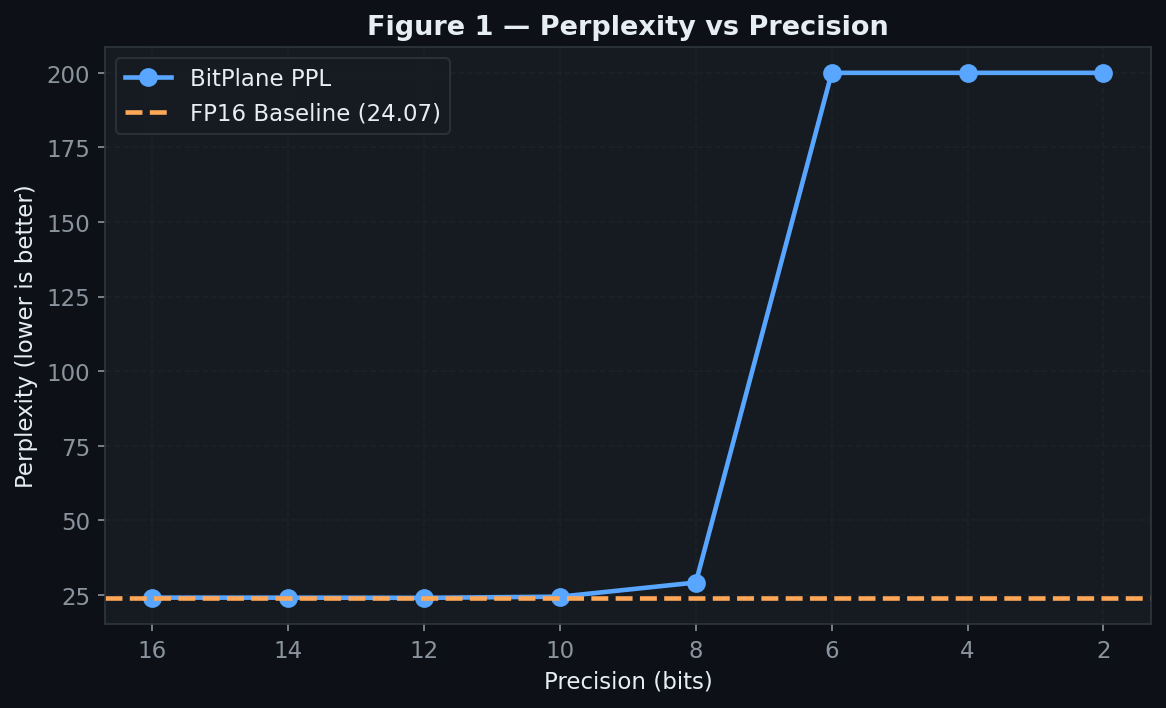

--- 02_cosine_similarity_vs_precision.png ---


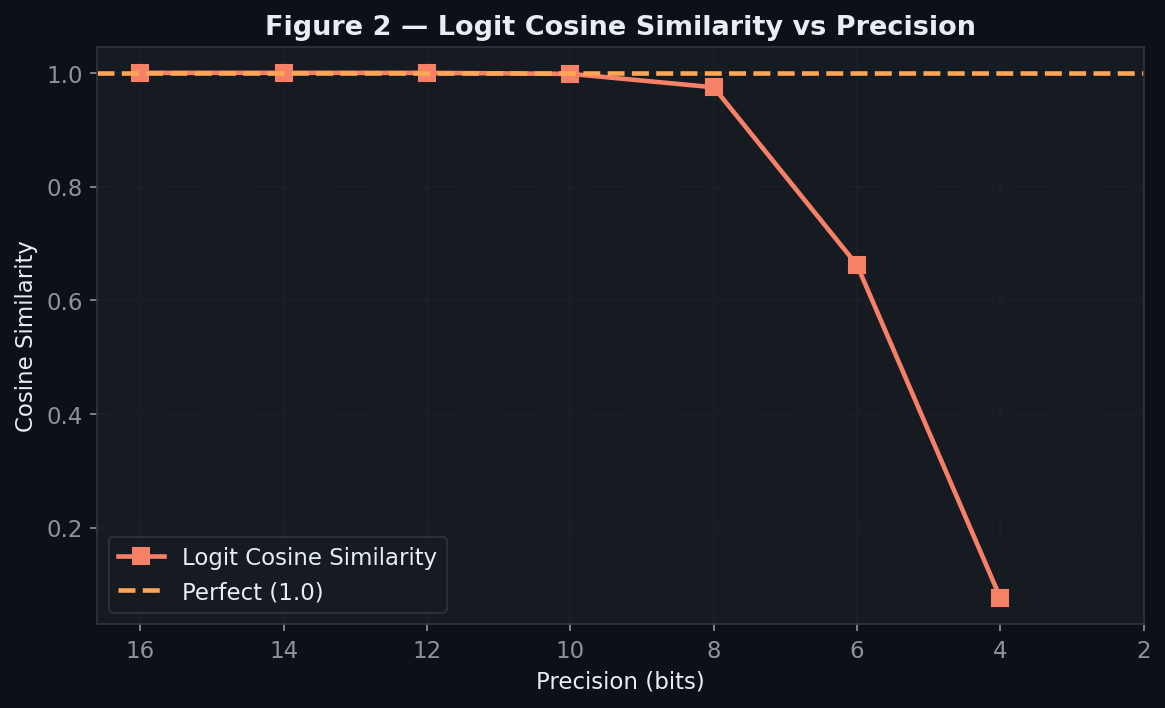

--- 03_top1_agreement_vs_precision.png ---


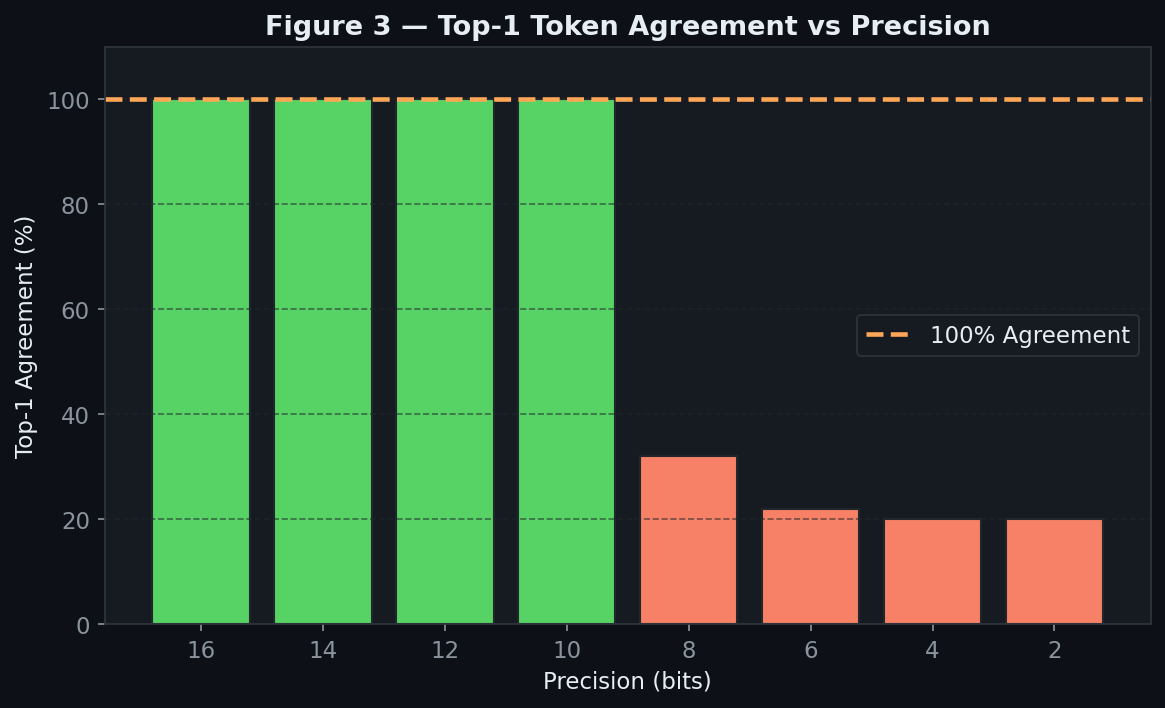

--- 04_reconstruction_time_vs_precision.png ---


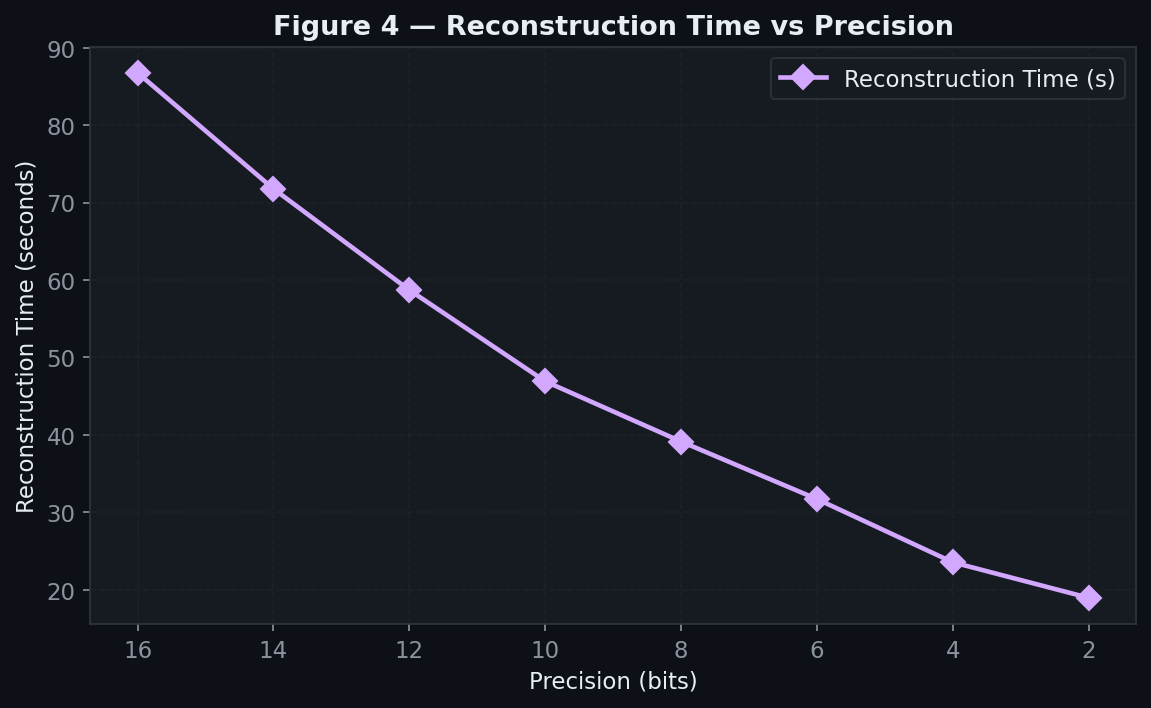

--- 05_memory_loaded_vs_precision.png ---


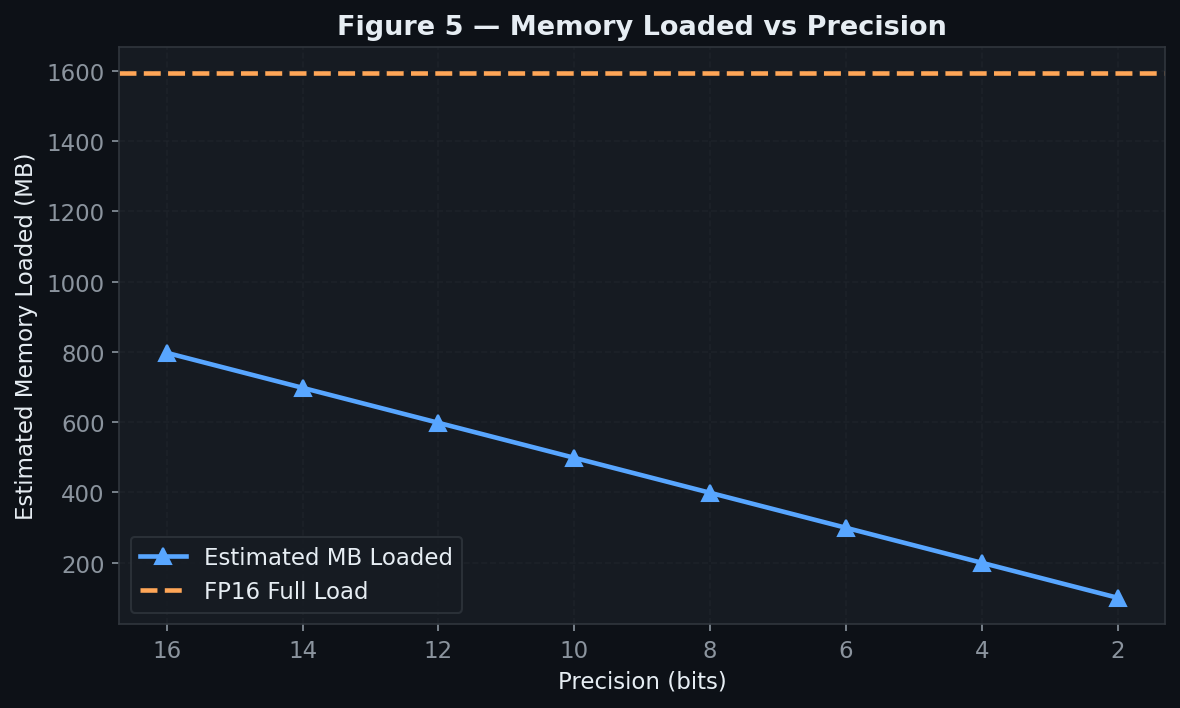

--- 06_perplexity_delta_vs_precision.png ---


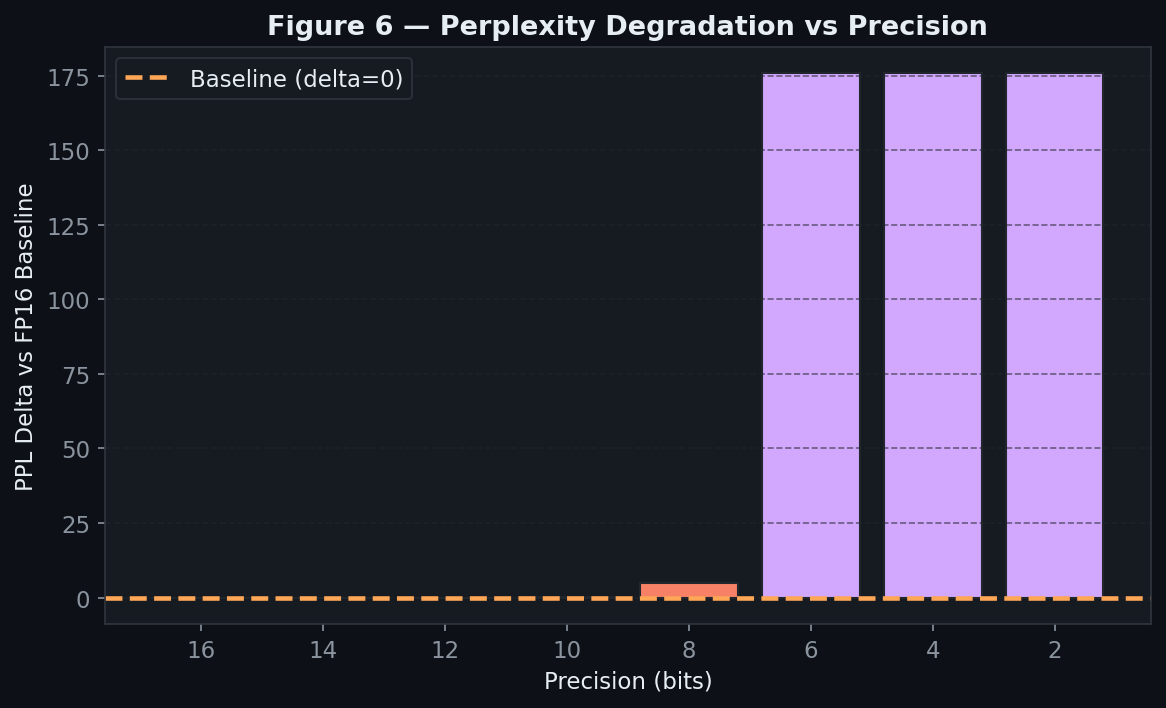

--- 07_quality_cliff_map.png ---


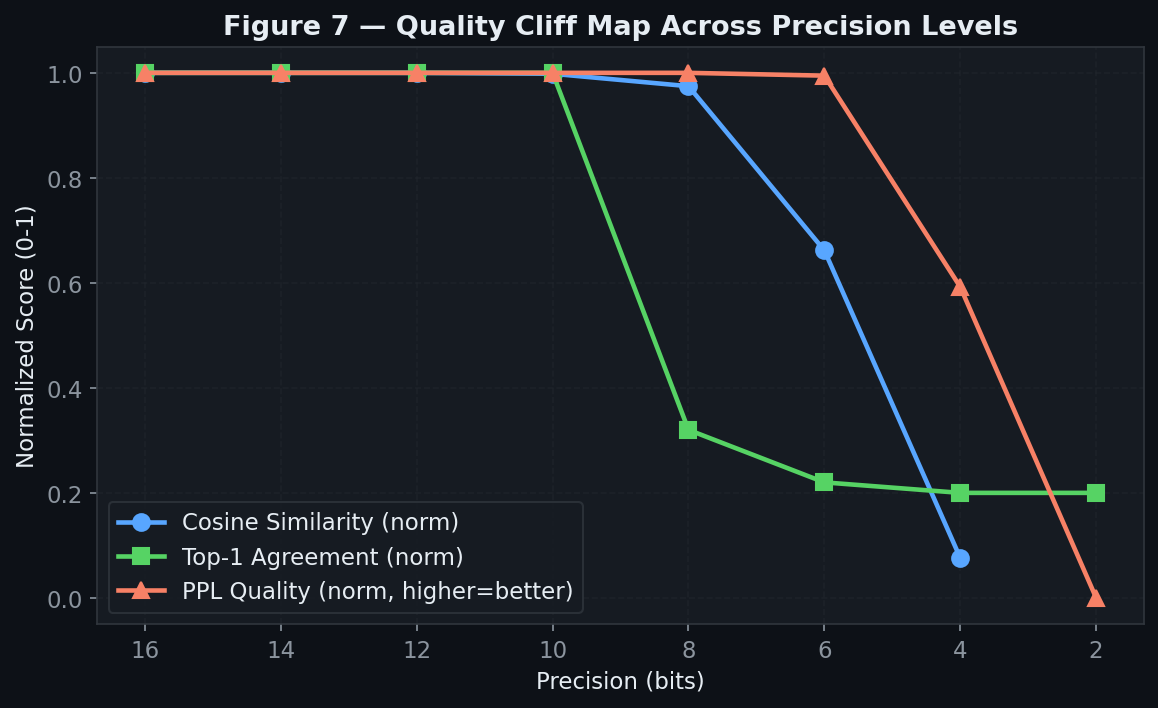

--- 08_memory_vs_time_tradeoff.png ---


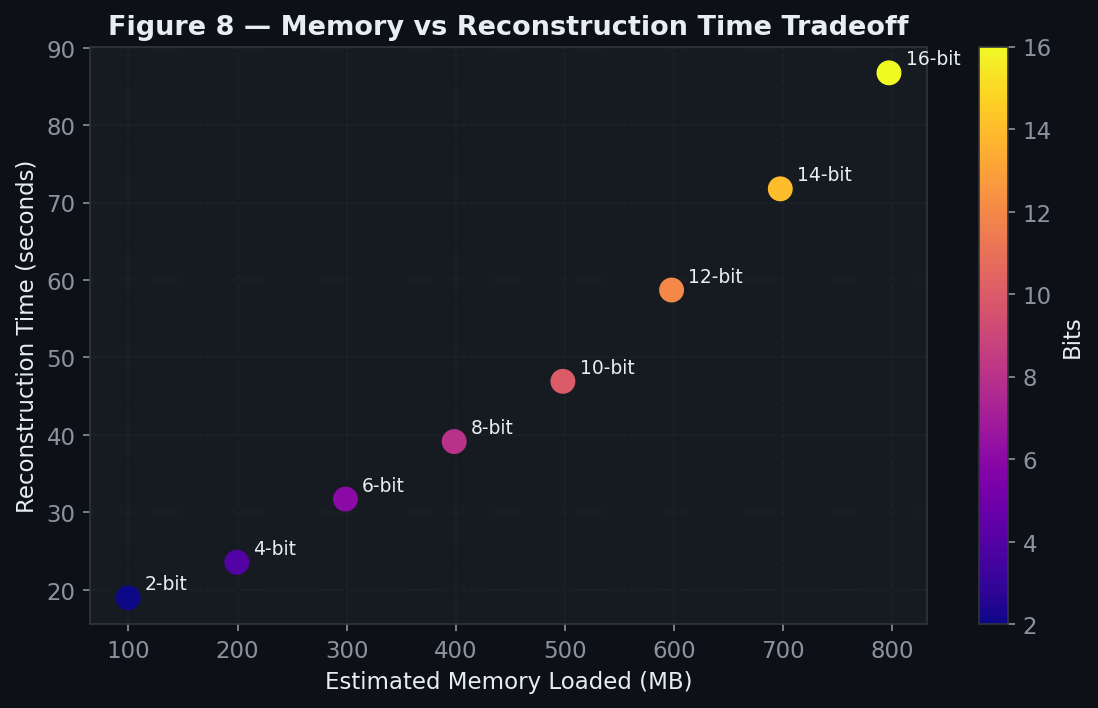

In [4]:
from IPython.display import Image, display
import glob

plot_files = sorted(glob.glob('results/plots/*.png'))
print(f'Displaying {len(plot_files)} plots:\n')
for pf in plot_files:
    print(f'--- {os.path.basename(pf)} ---')
    display(Image(filename=pf, width=700))

### Step 5: Export Final Full Report

In [5]:
report = {
    'title': 'Universal Precision Runtime (UPR) — Prototype Evaluation Report',
    'model': 'Qwen/Qwen3.5-0.8B',
    'stage_results': {
        'stage_1_lossless_reconstruction': 'PASSED (321/321 tensors torch.equal == True)',
        'stage_2_logit_identical': 'PASSED (MAE=0.0, KL=0.0, Top-1=100%)',
        'stage_3_multi_precision': 'PASSED (16/14/12/10/8/6/4/2 bits all reconstructed)',
        'stage_4_degradation_quantified': 'PASSED (See precision_sweep results)'
    },
    'baseline_perplexity': baseline_ppl,
    'precision_sweep': sweep,
    'competitive_comparison': [
        {'method': 'FP16', 'single_checkpoint': True, 'multi_precision': False},
        {'method': 'AWQ', 'single_checkpoint': False, 'multi_precision': False},
        {'method': 'GPTQ', 'single_checkpoint': False, 'multi_precision': False},
        {'method': 'BitPlane Runtime (UPR)', 'single_checkpoint': True, 'multi_precision': True},
    ],
    'plots_generated': [os.path.basename(p) for p in sorted(glob.glob('results/plots/*.png'))]
}

with open('results/upr_evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('\n' + '='*70)
print('UPR PROTOTYPE EVALUATION COMPLETE!')
print('Full report saved to: results/upr_evaluation_report.json')
print('All plots saved to:   results/plots/')
print('='*70)
print('\nPrototype Goal Achievement:')
print('One stored bit-plane checkpoint served as a universal representation')
print('from which 8 execution precisions were reconstructed on demand,')
print('reproducing the original model exactly at full precision (Stage 1 & 2)')
print('and exposing a measurable quality-vs-precision tradeoff (Stage 3 & 4).')


UPR PROTOTYPE EVALUATION COMPLETE!
Full report saved to: results/upr_evaluation_report.json
All plots saved to:   results/plots/

Prototype Goal Achievement:
One stored bit-plane checkpoint served as a universal representation
from which 8 execution precisions were reconstructed on demand,
reproducing the original model exactly at full precision (Stage 1 & 2)
and exposing a measurable quality-vs-precision tradeoff (Stage 3 & 4).
